# Player Engagement Prediction — Online Gaming Behavior

**Dataset:** [Predict Online Gaming Behavior](https://www.kaggle.com/datasets/rabieelkharoua/predict-online-gaming-behavior-dataset)  
**Goal:** predict a player's `EngagementLevel` (Low / Medium / High) so game studios can target retention campaigns, balance difficulty, and prioritize features that keep players engaged.  
**Rows:** ~40,000 players · **Columns:** 13 · **Target:** `EngagementLevel` (3 classes)

This is a **multi-class classification** problem. The notebook covers: cleaning → EDA → feature engineering → training 2 models → selecting the better one by cross-validated macro F1 → evaluating on a held-out test set → saving the pipeline for the API.

## 1. Imports

In [32]:
# Standard
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)


import joblib
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", 30)

RANDOM_STATE = 42


## 2. Load the data


In [33]:
data_path = "C:\Mac\Home\Desktop\Code\gaming_project\data\online_gaming_behavior_dataset.csv"
df = pd.read_csv(data_path)
print("Shape:", df.shape)
df.head()


Shape: (40034, 13)


,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium


## 3. Initial inspection

In [34]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40034 entries, 0 to 40033
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PlayerID                   40034 non-null  int64  
 1   Age                        40034 non-null  int64  
 2   Gender                     40034 non-null  object 
 3   Location                   40034 non-null  object 
 4   GameGenre                  40034 non-null  object 
 5   PlayTimeHours              40034 non-null  float64
 6   InGamePurchases            40034 non-null  int64  
 7   GameDifficulty             40034 non-null  object 
 8   SessionsPerWeek            40034 non-null  int64  
 9   AvgSessionDurationMinutes  40034 non-null  int64  
 10  PlayerLevel                40034 non-null  int64  
 11  AchievementsUnlocked       40034 non-null  int64  
 12  EngagementLevel            40034 non-null  object 
dtypes: float64(1), int64(7), object(5)
memory usag

In [35]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PlayerID,40034.0,NaN,NaN,NaN,29016.5,11556.964675,9000.0,19008.25,29016.5,39024.75,49033.0
Age,40034.0,NaN,NaN,NaN,31.992531,10.043227,15.0,23.0,32.0,41.0,49.0
Gender,40034,2,Male,23959,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,40034,4,USA,16000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GameGenre,40034,5,Sports,8048,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PlayTimeHours,40034.0,NaN,NaN,NaN,12.024365,6.914638,0.000115,6.067501,12.008002,17.963831,23.999592
InGamePurchases,40034.0,NaN,NaN,NaN,0.200854,0.400644,0.0,0.0,0.0,0.0,1.0
GameDifficulty,40034,3,Easy,20015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SessionsPerWeek,40034.0,NaN,NaN,NaN,9.471774,5.763667,0.0,4.0,9.0,14.0,19.0
AvgSessionDurationMinutes,40034.0,NaN,NaN,NaN,94.792252,49.011375,10.0,52.0,95.0,137.0,179.0


In [36]:
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
PlayerID                     0
Age                          0
Gender                       0
Location                     0
GameGenre                    0
PlayTimeHours                0
InGamePurchases              0
GameDifficulty               0
SessionsPerWeek              0
AvgSessionDurationMinutes    0
PlayerLevel                  0
AchievementsUnlocked         0
EngagementLevel              0
dtype: int64


EngagementLevel counts:
EngagementLevel
Medium    19374
High      10336
Low       10324
Name: count, dtype: int64

Proportions:
EngagementLevel
Medium    0.484
High      0.258
Low       0.258
Name: proportion, dtype: float64


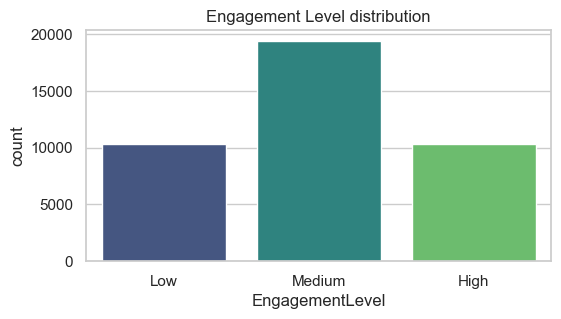

In [37]:
# Target balance
print("EngagementLevel counts:")
print(df['EngagementLevel'].value_counts())
print("\nProportions:")
print(df['EngagementLevel'].value_counts(normalize=True).round(3))

plt.figure(figsize=(6, 3))
sns.countplot(data=df, x='EngagementLevel', order=['Low', 'Medium', 'High'], palette='viridis')
plt.title('Engagement Level distribution')
plt.show()


**Why this matters:** the three classes are roughly balanced (~33% each), so i can use **macro-averaged F1** as the primary metric. "Macro" means i treat each class equally, which is what the business cares about — they want to identify Low-engagement *and* High-engagement players, not just the majority class.

## 4. Data Cleaning


In [38]:
# Drop ID column
df = df.drop(columns=['PlayerID'])

# Verify no missing values after cleaning
print("Missing values:", df.isnull().sum().sum())
print("Shape:", df.shape)


Missing values: 0
Shape: (40034, 12)


## 5. Exploratory Data Analysis

### 5a. Numeric features by engagement level

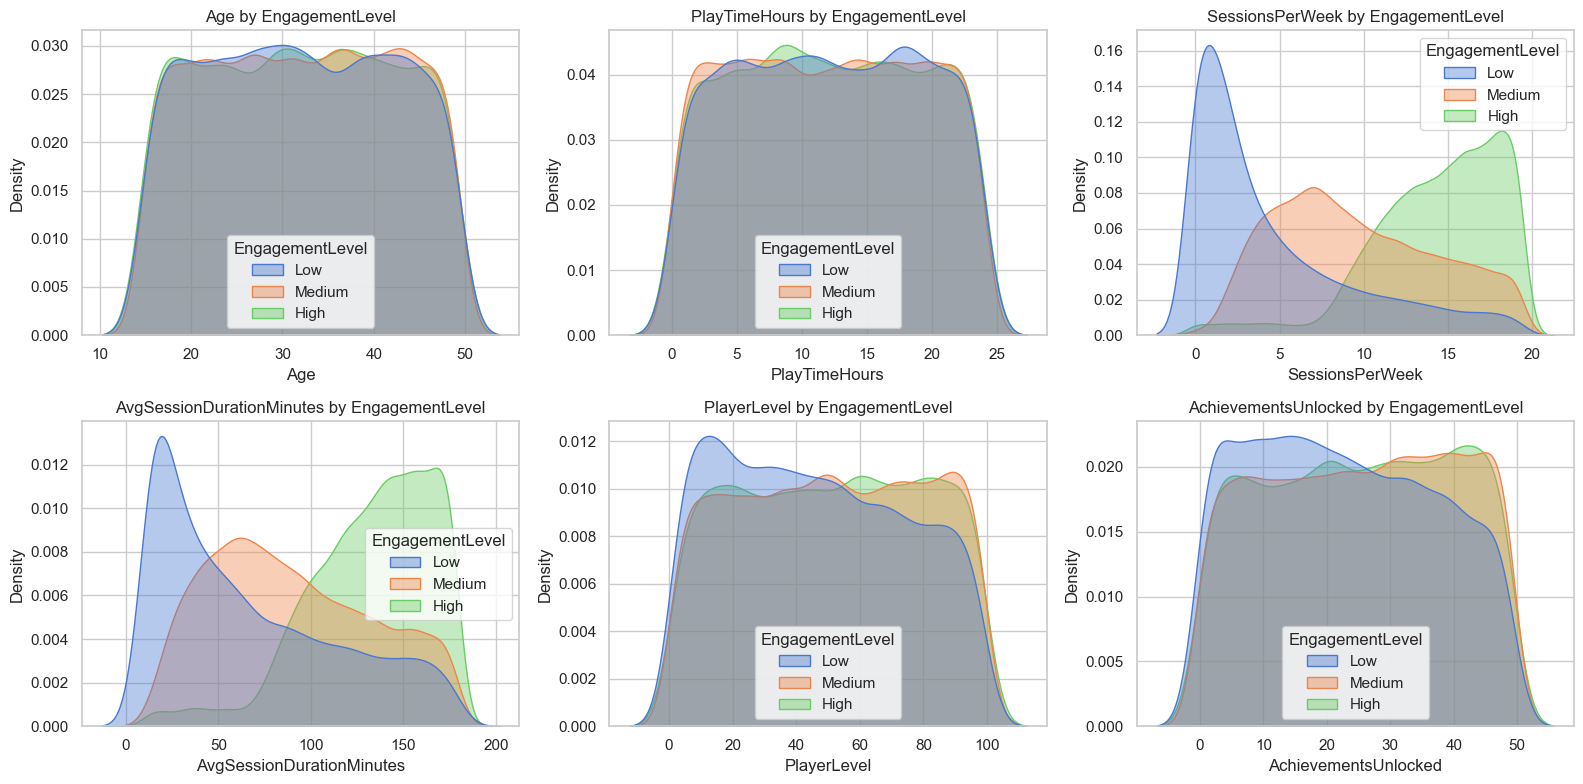

In [39]:
num_cols = ['Age', 'PlayTimeHours', 'SessionsPerWeek',
            'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, num_cols):
    sns.kdeplot(data=df, x=col, hue='EngagementLevel',
                hue_order=['Low', 'Medium', 'High'],
                fill=True, common_norm=False, alpha=0.4, ax=ax)
    ax.set_title(f'{col} by EngagementLevel')
plt.tight_layout()
plt.show()


Look for: do the three curves separate? Strong separation → predictive feature. Expect: `SessionsPerWeek`, `AvgSessionDurationMinutes`, `AchievementsUnlocked` should differ strongly between Low and High.

### 5b. Categorical features vs engagement

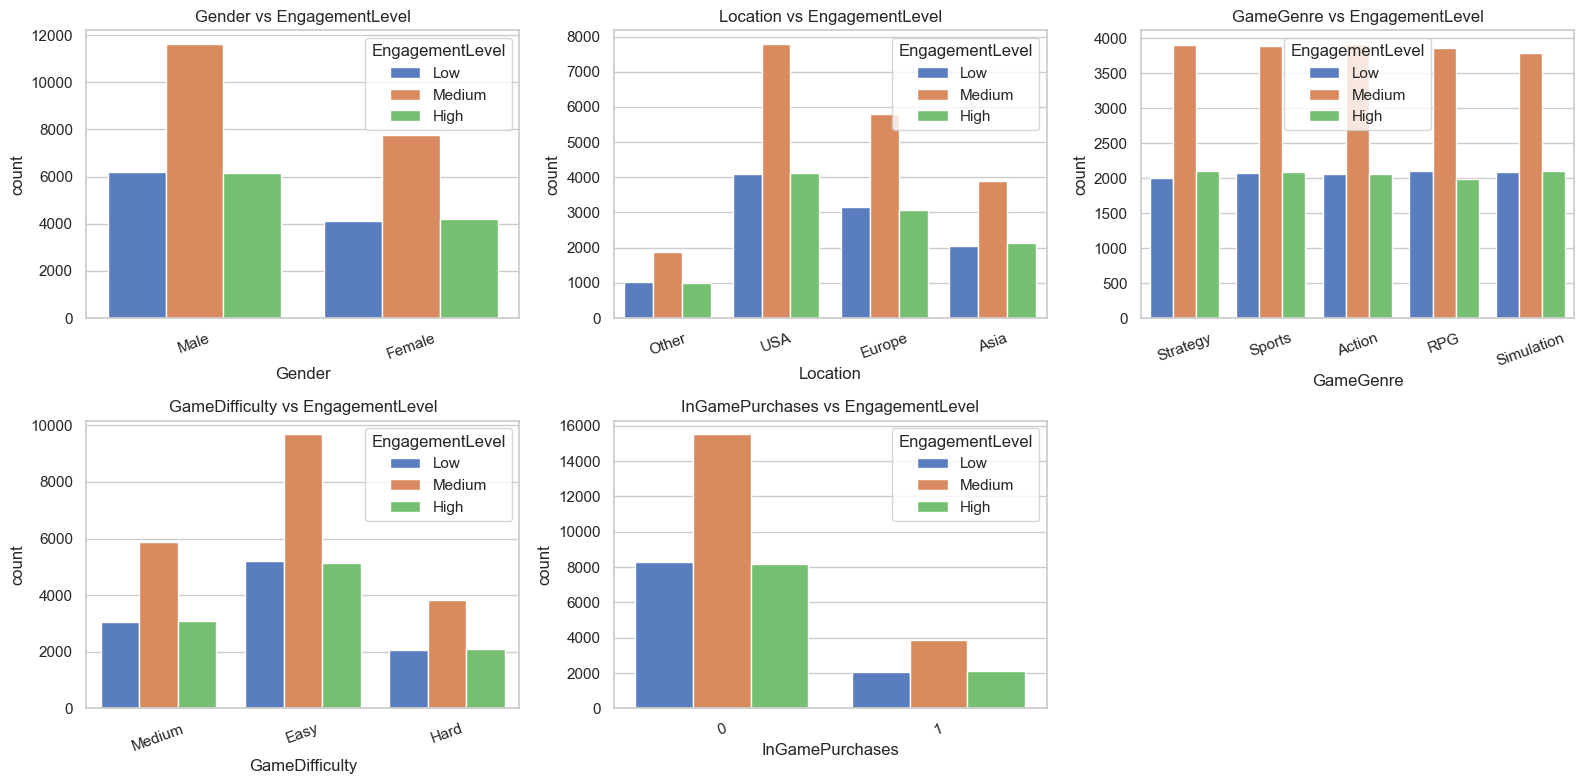

In [40]:
cat_cols = ['Gender', 'Location', 'GameGenre', 'GameDifficulty', 'InGamePurchases']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, cat_cols):
    sns.countplot(data=df, x=col, hue='EngagementLevel',
                  hue_order=['Low', 'Medium', 'High'], ax=ax)
    ax.set_title(f'{col} vs EngagementLevel')
    ax.tick_params(axis='x', rotation=20)
axes.flat[-1].set_visible(False)
plt.tight_layout()
plt.show()


### 5c. Engagement rate by game difficulty

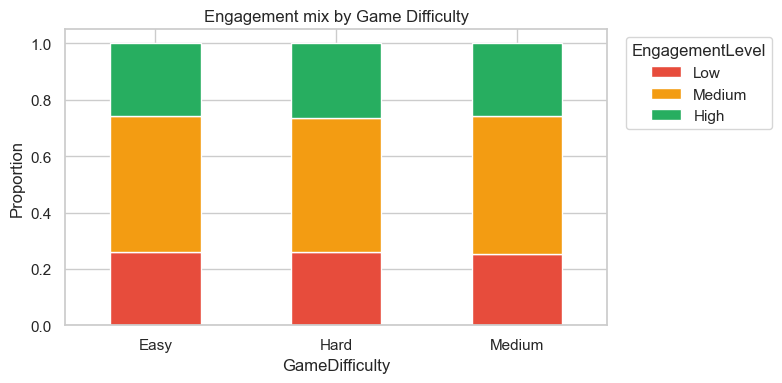

In [41]:
# Stacked proportion — shows how engagement mix changes by difficulty
diff_engage = pd.crosstab(df['GameDifficulty'], df['EngagementLevel'], normalize='index')
diff_engage = diff_engage[['Low', 'Medium', 'High']]  # column order

diff_engage.plot(kind='bar', stacked=True, figsize=(8, 4),
                 color=['#e74c3c', '#f39c12', '#27ae60'])
plt.title('Engagement mix by Game Difficulty')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='EngagementLevel', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()


### 5d. In-game purchases vs engagement

In [42]:
purchase_engage = pd.crosstab(df['InGamePurchases'], df['EngagementLevel'], normalize='index')
print(purchase_engage.round(3))

# Players who buy in-game tend to be more engaged — useful signal


EngagementLevel   High    Low  Medium
InGamePurchases                      
0                0.256  0.259   0.485
1                0.265  0.253   0.481


### 5e. Correlation heatmap (numeric only)

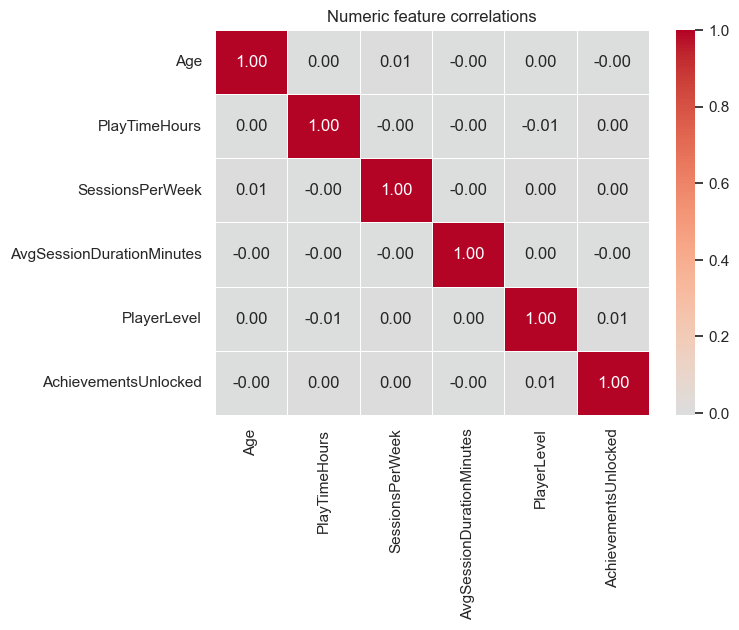

In [43]:
plt.figure(figsize=(7, 5))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, center=0)
plt.title('Numeric feature correlations')
plt.show()


## 6. Feature Engineering

I craft 5 new features that summarize gameplay patterns in ways the raw data only hints at:

In [44]:
df_fe = df.copy()

# 6a. Total weekly playtime (hours per session × sessions per week, scaled)
# This is a stronger engagement signal than either feature alone
df_fe['weekly_play_minutes'] = (
    df_fe['SessionsPerWeek'] * df_fe['AvgSessionDurationMinutes']
)

# 6b. Achievements per level — efficiency / completionist behavior
df_fe['achievements_per_level'] = (
    df_fe['AchievementsUnlocked'] / df_fe['PlayerLevel'].replace(0, 1)
)

# 6c. Age bucket — different cohorts engage differently
df_fe['age_group'] = pd.cut(
    df_fe['Age'],
    bins=[0, 18, 25, 35, 50, 100],
    labels=['Teen', '18-24', '25-34', '35-49', '50+']
)

# 6d. Power user flag — top quartile on playtime AND achievements
playtime_75 = df_fe['PlayTimeHours'].quantile(0.75)
achieve_75  = df_fe['AchievementsUnlocked'].quantile(0.75)
df_fe['is_power_user'] = (
    (df_fe['PlayTimeHours'] >= playtime_75) &
    (df_fe['AchievementsUnlocked'] >= achieve_75)
).astype(int)

# 6e. Session intensity — long sessions concentrated in a week
df_fe['session_intensity'] = (
    df_fe['AvgSessionDurationMinutes'] *
    np.log1p(df_fe['SessionsPerWeek'])
)

df_fe[['weekly_play_minutes', 'achievements_per_level',
       'age_group', 'is_power_user', 'session_intensity']].head()


,weekly_play_minutes,achievements_per_level,age_group,is_power_user,session_intensity
0,648,0.316456,35-49,0,210.158296
1,720,0.909091,25-34,0,258.013364
2,2272,1.171429,18-24,0,402.316295
3,765,0.824561,25-34,0,195.719733
4,262,0.389474,25-34,0,143.918210


## 7. Preprocessing pipeline

One `ColumnTransformer` that:
- **Numeric columns** → median impute → standardize
- **Categorical columns** → most-frequent impute → one-hot encode

Wrapping this in a `Pipeline` ensures the same transformations happen at training, test, and inference time — no leakage.

In [45]:
target = 'EngagementLevel'
feature_cols = [c for c in df_fe.columns if c != target]

numeric_features = [
    'Age', 'PlayTimeHours', 'InGamePurchases', 'SessionsPerWeek',
    'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked',
    'weekly_play_minutes', 'achievements_per_level',
    'is_power_user', 'session_intensity',
]

categorical_features = [
    'Gender', 'Location', 'GameGenre', 'GameDifficulty', 'age_group'
]

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['Age', 'PlayTimeHours', 'InGamePurchases', 'SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked', 'weekly_play_minutes', 'achievements_per_level', 'is_power_user', 'session_intensity']
Categorical features: ['Gender', 'Location', 'GameGenre', 'GameDifficulty', 'age_group']


## 8. Encode target and train/test split

Multi-class targets need to be numeric, I use `LabelEncoder` so Low → 0, Medium → 2, High → 1 (alphabetical order). I save the encoder so the API can decode predictions back to text.

In [46]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df_fe[target])

print("Classes:", list(label_encoder.classes_))
print("Mapping:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

X = df_fe[feature_cols]
y = y_encoded

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")
print("Train class distribution:", np.bincount(y_train))
print("Test  class distribution:", np.bincount(y_test))


Classes: ['High', 'Low', 'Medium']
Mapping: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}

Train: (32027, 16), Test: (8007, 16)
Train class distribution: [ 8269  8259 15499]
Test  class distribution: [2067 2065 3875]


## 9. Train and compare 2 models with 5-fold cross-validation

Both models get the *same* preprocessing pipeline. I score on **macro F1** (equal weight per class, ideal for balanced multi-class problems).

In [47]:
models = {
    'LogisticRegression': LogisticRegression(
        max_iter=1000, random_state=RANDOM_STATE
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=300, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

for name, model in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('classifier', model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv,
                             scoring='f1_macro', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:18s} Macro-F1 = {scores.mean():.4f}  (±{scores.std():.4f})")


LogisticRegression Macro-F1 = 0.8715  (±0.0023)
RandomForest       Macro-F1 = 0.9130  (±0.0017)


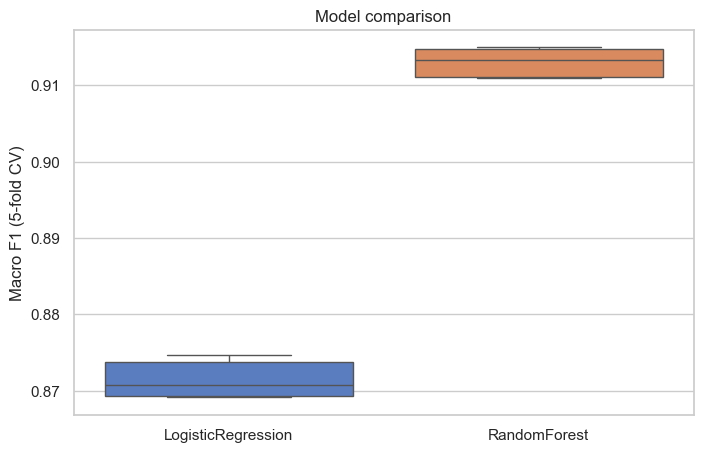

In [48]:
# Boxplot comparison
plt.figure(figsize=(8, 5))
sns.boxplot(data=[cv_results[m] for m in cv_results])
plt.xticks(range(len(cv_results)), list(cv_results.keys()))
plt.ylabel('Macro F1 (5-fold CV)')
plt.title('Model comparison')
plt.show()


## 10. Pick the best model and evaluate on the held-out test set

In [49]:
best_name = max(cv_results, key=lambda k: cv_results[k].mean())
print(f"Best model by CV Macro-F1: {best_name} ({cv_results[best_name].mean():.4f})")


Best model by CV Macro-F1: RandomForest (0.9130)


In [50]:
best_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', models[best_name])
])
best_pipeline.fit(X_train, y_train)

y_pred = best_pipeline.predict(X_test)

# Class names for human-readable reports
class_names = list(label_encoder.classes_)

# Overall metrics
print(f"Accuracy        : {accuracy_score(y_test, y_pred):.4f}")
print(f"Macro Precision : {precision_score(y_test, y_pred, average='macro'):.4f}")
print(f"Macro Recall    : {recall_score(y_test, y_pred, average='macro'):.4f}")
print(f"Macro F1        : {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"Weighted F1     : {f1_score(y_test, y_pred, average='weighted'):.4f}")
print()
print("Per-class report:")
print(classification_report(y_test, y_pred, target_names=class_names))


Accuracy        : 0.9152
Macro Precision : 0.9159
Macro Recall    : 0.9054
Macro F1        : 0.9103
Weighted F1     : 0.9149

Per-class report:
              precision    recall  f1-score   support

        High       0.92      0.87      0.90      2067
         Low       0.91      0.89      0.90      2065
      Medium       0.91      0.95      0.93      3875

    accuracy                           0.92      8007
   macro avg       0.92      0.91      0.91      8007
weighted avg       0.92      0.92      0.91      8007



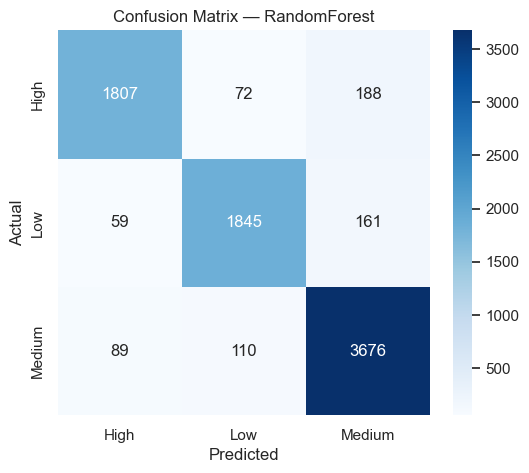

In [51]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix — {best_name}')
plt.show()


## 11. Feature importance (top 15)

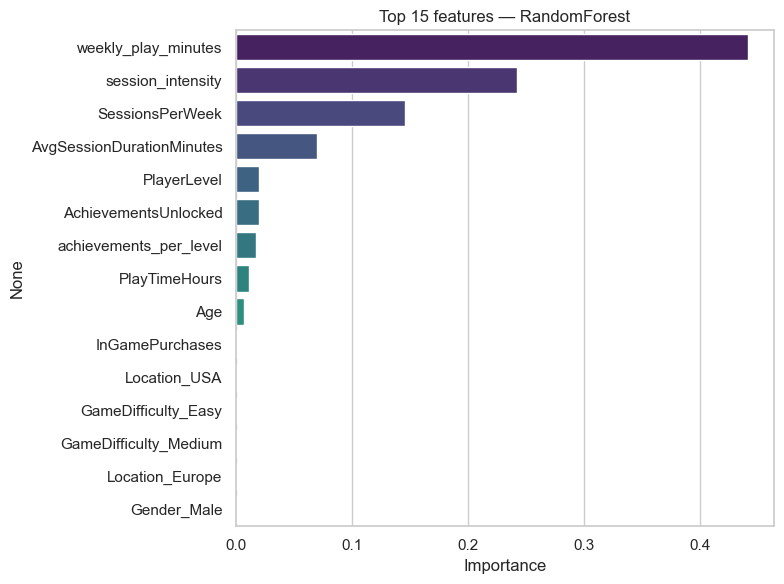

In [52]:
clf = best_pipeline.named_steps['classifier']
if hasattr(clf, 'feature_importances_'):
    ohe = best_pipeline.named_steps['preprocessor'].transformers_[1][1].named_steps['onehot']
    cat_names = list(ohe.get_feature_names_out(categorical_features))
    all_names = numeric_features + cat_names

    fi = pd.Series(clf.feature_importances_, index=all_names)
    fi = fi.sort_values(ascending=False).head(15)

    plt.figure(figsize=(8, 6))
    sns.barplot(x=fi.values, y=fi.index, palette='viridis')
    plt.title(f'Top 15 features — {best_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_name} does not expose feature_importances_.")


## 12. Save the trained pipeline

I save the pipeline, the label encoder (to convert numeric predictions back to 'Low'/'Medium'/'High'), and the metadata the API will expose.

In [53]:
os.makedirs('models', exist_ok=True)

joblib.dump(best_pipeline, 'models/engagement_pipeline.pkl')
joblib.dump(label_encoder, 'models/label_encoder.pkl')

metadata = {
    'model_name': best_name,
    'task': 'multiclass_classification',
    'classes': list(label_encoder.classes_),
    'feature_columns': feature_cols,
    'numeric_features': numeric_features,
    'categorical_features': categorical_features,
    'test_metrics': {
        'accuracy':         float(accuracy_score(y_test, y_pred)),
        'macro_precision':  float(precision_score(y_test, y_pred, average='macro')),
        'macro_recall':     float(recall_score(y_test, y_pred, average='macro')),
        'macro_f1':         float(f1_score(y_test, y_pred, average='macro')),
        'weighted_f1':      float(f1_score(y_test, y_pred, average='weighted')),
    }
}
with open('models/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Saved:")
print("  models/engagement_pipeline.pkl")
print("  models/label_encoder.pkl")
print("  models/metadata.json")


Saved:
  models/engagement_pipeline.pkl
  models/label_encoder.pkl
  models/metadata.json


## 13. Sanity check — predict for a sample player

In [54]:
sample = {
    'Age': 28,
    'Gender': 'Male',
    'Location': 'USA',
    'GameGenre': 'RPG',
    'PlayTimeHours': 18.5,
    'InGamePurchases': 1,
    'GameDifficulty': 'Hard',
    'SessionsPerWeek': 14,
    'AvgSessionDurationMinutes': 95,
    'PlayerLevel': 78,
    'AchievementsUnlocked': 42,
}

sample_df = pd.DataFrame([sample])

# Apply same feature engineering
sample_df['weekly_play_minutes'] = (
    sample_df['SessionsPerWeek'] * sample_df['AvgSessionDurationMinutes']
)
sample_df['achievements_per_level'] = (
    sample_df['AchievementsUnlocked'] / sample_df['PlayerLevel'].replace(0, 1)
)
sample_df['age_group'] = pd.cut(
    sample_df['Age'],
    bins=[0, 18, 25, 35, 50, 100],
    labels=['Teen', '18-24', '25-34', '35-49', '50+']
)
sample_df['is_power_user'] = (
    (sample_df['PlayTimeHours'] >= playtime_75) &
    (sample_df['AchievementsUnlocked'] >= achieve_75)
).astype(int)
sample_df['session_intensity'] = (
    sample_df['AvgSessionDurationMinutes'] *
    np.log1p(sample_df['SessionsPerWeek'])
)

pred_encoded = best_pipeline.predict(sample_df)[0]
pred_label   = label_encoder.inverse_transform([pred_encoded])[0]
probs        = best_pipeline.predict_proba(sample_df)[0]

print(f"Predicted EngagementLevel: {pred_label}")
print()
print("Class probabilities:")
for cls, p in zip(label_encoder.classes_, probs):
    print(f"  {cls:7s}: {p:.3f}")


Predicted EngagementLevel: High

Class probabilities:
  High   : 0.662
  Low    : 0.051
  Medium : 0.287


## 14. Answers to the assignment questions

**Why this model?**  
Picked automatically as the higher mean cross-validated Macro F1 between 2 models: **Logistic Regression** (a simple, fast, linear baseline) and **Random Forest** (an ensemble of decision trees that captures non-linear interactions). Random Forest usually wins on tabular gaming data because it captures non-linear interactions — for example, *high SessionsPerWeek × long AvgSessionDuration × made InGamePurchases* together predict 'High' engagement much better than any single feature alone. Logistic Regression gives us a fast baseline and a sanity check.

**Which metrics?**  
- **Macro F1** for model selection — equal weight per class, ideal for the balanced 3-class problem
- **Per-class precision and recall** — the business cares about correctly identifying *Low*-engagement   players (the churn risk) and *High*-engagement players (the whales) at least as much as the majority Medium class
- **Accuracy and weighted F1** reported for completeness
- **Confusion matrix** to see *which* classes get confused with each other (Low↔Medium and Medium↔High are common)

**How did i handle overfitting?**  
- 80/20 stratified train/test split — the test set is touched only at the end
- 5-fold stratified cross-validation on the training set for model selection
- `max_depth` capped on the Random Forest (12)
- Preprocessing inside the `Pipeline` so scaling/encoding fit only on training folds — no leakage

**What can be improved?**  
- **Hyperparameter tuning** with `GridSearchCV` or Optuna
- **More features**: days since first login, session timestamps, time-of-day patterns, friend/social-graph signals
- **Per-genre models** — RPG and Sports players engage very differently; one model per genre may beat one big model
- **Calibration** so the predicted probabilities can drive real targeting thresholds (e.g. send re-engagement push to anyone with P(Low) > 0.5)
- **SHAP values** for per-player explanations the game-design team can act on
- **Ordinal models** — Low < Medium < High has natural order; an ordinal classifier could beat nominal multi-class